# SR3 RV Lab — Framework 6: curvature vs vol, and the vol surface's own shape

**RV class: A / C.**

Three related questions, all marked on listed prices:

* **6a Fly vs straddle** — the futures butterfly prices the *velocity* of the
  policy path; the belly straddle prices its *dispersion*. Both are claims on
  the same random path but neither pins the other, so their relative richness
  is a real basis. The package is the belly straddle against the `+1/-2/+1`
  futures fly, delta-hedged daily so the straddle's own direction is removed.
* **6b Vol butterfly** — `½(hike_iv + cut_iv) - atm_iv`, the smile's curvature
  in listed normal-vol terms, traded as a strangle against a vega-matched
  straddle. Bimodal policy pricing bids the wings; a diffuse path bids the ATM.
* **6c Skew term structure** — the risk reversal *in vol space* differenced
  across adjacent expiries: does hike/cut skew live in the near window or the
  far one, and does the spread revert or trend?

In [1]:
CONFIG = dict(
    wing_offset=0.25,
    strike_tol=0.13,
    min_oi=100,
    min_tte=0.15,
    contracts_per_leg=100,
    cost_bp=2.5,
    mas=(1, 5, 10),
    zscore_windows=(60, 120),
    entry_zs=(1.0, 1.5, 2.0),
    exits=("t5", "t10", "z0"),
    directions=("fade", "momentum"),
)
CONFIG

{'wing_offset': 0.25,
 'strike_tol': 0.13,
 'min_oi': 100,
 'min_tte': 0.15,
 'contracts_per_leg': 100,
 'cost_bp': 2.5,
 'mas': (1, 5, 10),
 'zscore_windows': (60, 120),
 'entry_zs': (1.0, 1.5, 2.0),
 'exits': ('t5', 't10', 'z0'),
 'directions': ('fade', 'momentum')}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import LabConfig, load_lab, run_framework
from RVUtils.SFRRVLab import (
    Leg, Structure, add_event_distance, atm_premium_panel,
    constant_maturity_slots, contract_pairs, quarterly_sort_key, vol_smile_panel,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]
tte = constant_maturity_slots(contracts)[["as_of", "symbol", "tte", "cm_slot"]]

atm = atm_premium_panel(quotes, contracts).merge(tte, on=["as_of", "symbol"])
atm = atm[atm["tte"] >= CONFIG["min_tte"]]
vs = vol_smile_panel(quotes, contracts, offset=CONFIG["wing_offset"],
                     tol=CONFIG["strike_tol"], min_oi=CONFIG["min_oi"])
vs = vs.merge(tte, on=["as_of", "symbol"])
vs = vs[vs["tte"] >= CONFIG["min_tte"]]
print(f"atm rows {len(atm)}   vol-smile rows {len(vs)}")
print(vs.groupby("symbol")[["atm_iv_bp", "rr_iv_bp", "fly_iv_bp"]].median()
      .round(2).to_string())

parity completion: 199319 listed quotes + 191259 reconstructed (96.0%) so ITM legs stay marked


atm rows 3797   vol-smile rows 3705
        atm_iv_bp  rr_iv_bp  fly_iv_bp
symbol                                
SFRH25      93.82    -13.95       0.68
SFRH26     102.27     -9.16      -0.03
SFRH27      89.72     -1.12       0.24
SFRH28     101.73      3.32       0.37
SFRM25      95.20    -14.99       0.19
SFRM26     102.66     -5.39      -0.06
SFRM27      89.78     -0.67       0.47
SFRM28     101.50      2.64       0.02
SFRU25      96.81    -14.25      -0.26
SFRU26      88.85     -2.50       0.02
SFRU27      86.40      0.15       0.50
SFRZ25      99.43    -11.80      -0.04
SFRZ26      82.78     -1.67       0.06
SFRZ27      97.48      1.72       0.44


## 6a — fly vs straddle

`signal = z(fly_bp) - z(belly straddle premium)`: the futures fly rich against
the belly's option-implied dispersion. Sign convention is the desk one,
`fly = 2*belly - front - back` in bp (note `BT/signals/sfr_cal_spread_rv.
compute_fly_curve` uses the opposite sign).

In [3]:
SYMS = sorted(contracts["symbol"].unique(), key=quarterly_sort_key)
TRIPLES = [(SYMS[i], SYMS[i + 1], SYMS[i + 2]) for i in range(len(SYMS) - 2)]
fwd = contracts.set_index(["as_of", "symbol"])["forward_rate"]
atm_idx = atm.set_index(["as_of", "symbol"])

rows = []
for a, b, c in TRIPLES:
    dates = sorted(set(atm_idx.xs(b, level="symbol").index))
    for ts in dates:
        try:
            fa, fb, fc = (float(fwd[(ts, a)]), float(fwd[(ts, b)]),
                          float(fwd[(ts, c)]))
            st = atm_idx.loc[(ts, b)]
        except KeyError:
            continue
        rows.append({
            "as_of": ts, "key": f"{a}-{b}-{c}", "front": a, "belly": b, "back": c,
            "fly_bp": (2 * fb - fa - fc) * 100.0,
            "straddle_bp": float(st["atm_straddle_bp"]),
            "belly_strike": float(st["atm_strike"]),
        })
fly = pd.DataFrame(rows)
if not fly.empty:
    g = fly.groupby("key")
    fly["fly_z"] = g["fly_bp"].transform(
        lambda s: (s - s.rolling(120, min_periods=40).mean())
        / s.rolling(120, min_periods=40).std(ddof=0))
    fly["str_z"] = g["straddle_bp"].transform(
        lambda s: (s - s.rolling(120, min_periods=40).mean())
        / s.rolling(120, min_periods=40).std(ddof=0))
    fly["signal"] = fly["fly_z"] - fly["str_z"]
    fly["gate"] = True
    fly = add_event_distance(fly.dropna(subset=["signal"]))
print(f"fly-vs-straddle rows: {len(fly)}  triples: "
      f"{fly['key'].nunique() if len(fly) else 0}")

fly-vs-straddle rows: 2489  triples: 11


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 6a. Fly vs belly straddle — grid ===
  108 configs | median -228.28bp | IQR [-501.89, -30.44] | 24% net-positive | best +290.82bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum  10            120               1.0         z0        61     0.590       4.768       290.822      727054.50   0.388   -275.167
 momentum  10            120               1.0        t10        93     0.602       3.051       283.745      709361.75   0.387   -363.077
 momentum  10            120               1.5         z0        39     0.667       6.940       270.646      676616.25   0.481   -288.426
 momentum   5            120               1.5         z0        45     0.600       5.325       239.604      599010.25   0.389   -302.485
 momentum   5             60               1.5         z0        61     0.541       3.918       239.005  

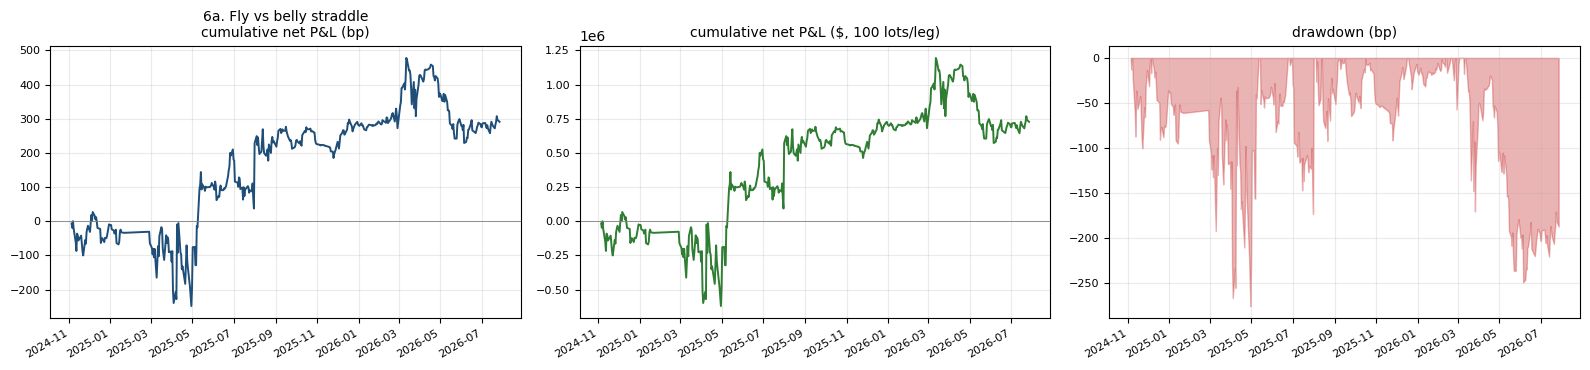


TRADE LOG (first rows)
                 key  dir                         structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp    net_usd  stale_frac  pkg_contracts    exit_reason
SFRH25-SFRM25-SFRU25    1 flyVstraddle SFRH25-SFRM25-SFRU25  2024-11-01 2024-11-04 2024-12-03    20  1.012  -16.3392      2.5 -18.8392  -47097.90         0.0            6.0       max_hold
SFRM25-SFRU25-SFRZ25    1 flyVstraddle SFRM25-SFRU25-SFRZ25  2024-11-05 2024-11-06 2024-12-05    20  1.241   11.2022      2.5   8.7022   21755.40         0.0            6.0       max_hold
SFRU25-SFRZ25-SFRH26    1 flyVstraddle SFRU25-SFRZ25-SFRH26  2024-11-07 2024-11-08 2024-12-09    20  1.039   18.7975      2.5  16.2975   40743.82         0.0            6.0       max_hold
SFRH25-SFRM25-SFRU25    1 flyVstraddle SFRH25-SFRM25-SFRU25  2024-12-04 2024-12-05 2025-01-06    20  1.081   -9.4019      2.5 -11.9019  -29754.71         0.0            6.0       max_hold
SFRM25-SFRU25-SFRZ25    1 flyVstradd

signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        63         336.106       178.606   0.221     0.508
       listed    1        61         443.322       290.822   0.388     0.590
same-bar (lag 0) gross inflation: -31.9%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 61       443.322       7.268     0.639      1108304.5
           0.5 61       412.822       6.768     0.639      1032054.5
           1.0 61       382.322       6.268     0.639       955804.5
           1.5 61       351.822       5.768     0.623       879554.5
           2.5 61       290.822       4.768     0.590       727054.5
           4.0 61       199.322       3.268     0.541       498304.5

6a. Fly vs belly straddle — median config (not selected)  |  fade|ma5|w120|z2.0|t10|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 6 contracts -> position = 600 contracts acr

In [4]:
FLY_IDX = fly.set_index(["key", "as_of"]).sort_index() if len(fly) else None


def builder_fly_straddle(key, exec_date, direction):
    """Belly straddle against the +1/-2/+1 futures fly, delta-hedged daily."""
    try:
        r = FLY_IDX.loc[(key, exec_date)]
    except (KeyError, AttributeError):
        return None
    if isinstance(r, pd.DataFrame):
        r = r.iloc[0]
    a, b, c = key.split("-")
    k = float(r["belly_strike"])
    return Structure((
        Leg("option", b, -1.0, "C", k), Leg("option", b, -1.0, "P", k),
        Leg("future", b, -2.0), Leg("future", a, 1.0), Leg("future", c, 1.0),
    ), label=f"flyVstraddle {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=0.25)
GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]

if len(fly):
    out_fly = run_framework(
        "6a. Fly vs belly straddle", signals=fly, book=lab["book"],
        builder=builder_fly_straddle, base=BASE, grid_spec=GRID, params=PARAMS,
        cls="A/C", note="futures fly against the belly straddle, hedged daily")

## 6b — vol butterfly (smile curvature)

Strangle against a vega-matched straddle. With both wings at the same offset
and near-equal vega, a 1:1 strangle-vs-straddle is the listed approximation;
the residual vega is small relative to the cost of refining it.

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 6b. Vol butterfly (smile curvature) — grid ===
  108 configs | median -441.09bp | IQR [-583.56, -338.76] | 0% net-positive | best -201.64bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10             60               2.0         z0        81     0.025      -2.489      -201.637     -504092.00  -5.311   -202.554
     fade  10            120               2.0         z0        82     0.012      -2.473      -202.763     -506906.25  -5.544   -203.680
 momentum  10             60               2.0         z0        81     0.037      -2.649      -214.566     -536414.75  -6.146   -216.963
 momentum  10            120               2.0         z0        82     0.024      -2.658      -217.938     -544844.75  -6.141   -220.334
     fade   5             60               2.0         z0        97     0.021      -2.409      

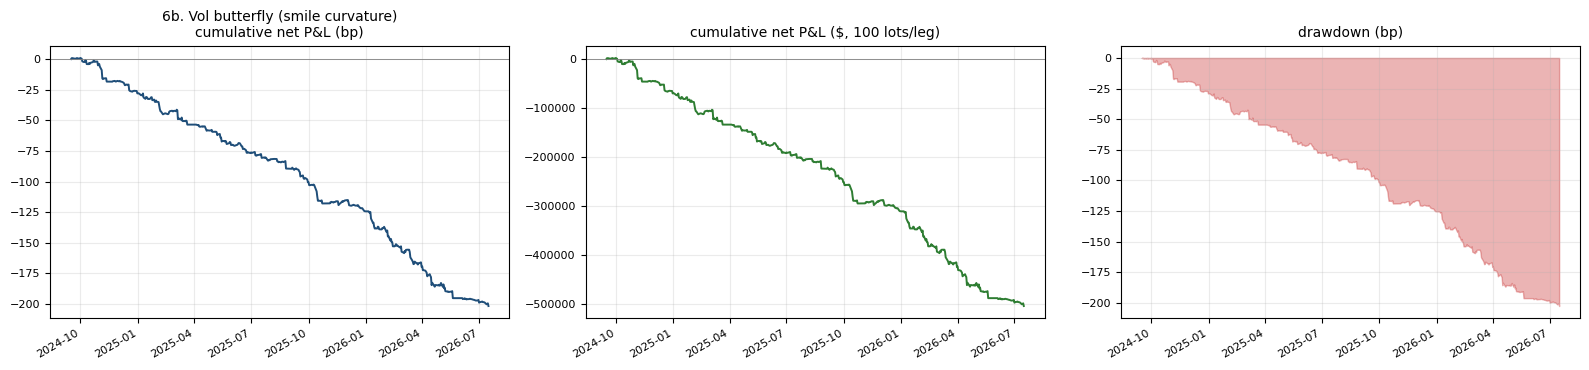


TRADE LOG (first rows)
   key  dir     structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp   net_usd  stale_frac  pkg_contracts    exit_reason
SFRH26   -1 volfly SFRH26  2024-09-11 2024-09-13 2024-10-11    20  3.037   -1.0855      2.5 -3.5855  -8963.71         0.0            4.0       max_hold
SFRM26   -1 volfly SFRM26  2024-09-30 2024-10-01 2024-10-29    20  2.025   -0.9667      2.5 -3.4667  -8666.73         0.0            4.0       max_hold
SFRZ25   -1 volfly SFRZ25  2024-10-03 2024-10-04 2024-11-01    20  2.014   -0.3530      2.5 -2.8530  -7132.56         0.0            4.0       max_hold
SFRU25   -1 volfly SFRU25  2024-10-04 2024-10-07 2024-11-04    20  2.340    0.1373      2.5 -2.3627  -5906.69         0.0            4.0       max_hold
SFRH25   -1 volfly SFRH25  2024-10-07 2024-10-08 2024-11-05    20  2.167    0.7485      2.5 -1.7515  -4378.77         0.0            4.0       max_hold
SFRM25   -1 volfly SFRM25  2024-10-07 2024-10-08 2024-11-05    2

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        81     0.025      -2.489      -201.637     -504092.00  -5.311   -202.554         14.778
half        81     0.012      -2.484      -201.226     -503065.25  -5.473   -201.980         13.494
  t5       132     0.008      -2.484      -327.867     -819668.25  -9.463   -328.600          4.909
 t10        97     0.010      -2.486      -241.112     -602779.50  -6.716   -241.866          9.680
 t20        74     0.014      -2.632      -194.761     -486903.75  -5.408   -195.678         19.365

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        82          23.321      -181.679  -5.250     0.024
       listed    1        81           0.863      -201.637  -5.311     0.025
same-bar (lag 0) gross inflation: 96.3%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 81         0.863       0.011     0.580         2158.0
           0.5 81       -39.637      -0.489     0.321       -99092.0
           1.0 81       -80.137      -0.989     0.148      -200342.0
           1.5 81      -120.637      -1.489     0.062      -301592.0
           2.5 81      -201.637      -2.489     0.025      -504092.0
           4.0 81      -323.137      -3.989     0.000      -807842.0



6b. Vol butterfly (smile curvature) — median config (not selected)  |  fade|ma1|w120|z2.0|t5|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 4 contracts -> position = 400 contracts across all legs
  trades   181   skipped    0   hit 1%   avg -2.420bp   avg hold 5.0d   stale 0.0%
  total    -437.96bp   $  -1,094,897   gross +14.54bp
  daily-MTM Sharpe -9.56   maxDD -438.36bp ($-1,095,907)   worst trade -5.26bp
  t(trade) -39.74   NW t(daily) -15.10   non-overlap SR -2.89   DSR p=0.000 over 108 trials

  LEAGUE ROW  6b. Vol butterfly (smile curvature) / best-config: MARGINAL-maker-only  (taker -201.64bp, maker +0.86bp, DSR p=0.000)

  LEAGUE ROW  6b. Vol butterfly (smile curvature) / median-config: MARGINAL-maker-only  (taker -437.96bp, maker +14.54bp, DSR p=0.000)


In [5]:
V = vs.rename(columns={"symbol": "key"}).copy()
V["gate"] = True
V = add_event_distance(V)
sig_flyiv = V[["key", "as_of", "gate", "days_to_fomc", "fly_iv_bp",
               "forward_rate"]].copy()
sig_flyiv["signal"] = sig_flyiv["fly_iv_bp"]

# strikes: re-derive from the forward exactly as vol_smile_panel did
from RVUtils.SFRRVLab import pick_listed_strike
QDAY = {k: v for k, v in quotes.groupby(["as_of", "symbol"], sort=False)}


def _smile_strikes(key, date):
    g = QDAY.get((pd.Timestamp(date), key))
    if g is None:
        return None
    f = fwd.get((pd.Timestamp(date), key))
    if f is None or not np.isfinite(f):
        return None
    atm_c = pick_listed_strike(g, "C", f, tol=CONFIG["strike_tol"])
    atm_p = pick_listed_strike(g, "P", f, tol=CONFIG["strike_tol"])
    hk = pick_listed_strike(g, "P", f + CONFIG["wing_offset"],
                            tol=CONFIG["strike_tol"])
    ct = pick_listed_strike(g, "C", f - CONFIG["wing_offset"],
                            tol=CONFIG["strike_tol"])
    if any(x is None for x in (atm_c, atm_p, hk, ct)):
        return None
    return (float(atm_c["strike_price"]), float(atm_p["strike_price"]),
            float(hk["strike_price"]), float(ct["strike_price"]))


def builder_vol_fly(key, exec_date, direction):
    ks = _smile_strikes(key, exec_date)
    if ks is None:
        return None
    kc, kp, khk, kct = ks
    return Structure((
        Leg("option", key, 1.0, "P", khk), Leg("option", key, 1.0, "C", kct),
        Leg("option", key, -1.0, "C", kc), Leg("option", key, -1.0, "P", kp),
    ), label=f"volfly {key}")


out_volfly = run_framework(
    "6b. Vol butterfly (smile curvature)", signals=sig_flyiv, book=lab["book"],
    builder=builder_vol_fly, base=BASE, grid_spec=GRID, params=PARAMS, cls="A",
    note="strangle vs straddle, delta-hedged daily")

## 6c — skew term structure (risk reversal in vol space, across expiries)

skew term-structure rows: 5770


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 6c. Skew term structure (vol space) — grid ===
  108 configs | median -756.95bp | IQR [-1044.39, -560.47] | 0% net-positive | best -291.01bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10             60               2.0         z0       113     0.027      -2.575      -291.013     -727532.75  -6.472   -291.175
     fade  10            120               2.0         z0       113     0.027      -2.783      -314.456     -786140.50  -6.287   -314.618
 momentum  10            120               2.0         z0       113     0.000      -3.046      -344.158     -860395.50  -6.849   -344.085
     fade   5             60               2.0         z0       130     0.023      -2.692      -350.013     -875032.50  -6.992   -350.044
     fade   5            120               2.0         z0       130     0.008      -2.784     


6c. Skew term structure (vol space) — best config  |  fade|ma10|w60|z2.0|z0|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  RR(back) - RR(front) in listed normal vol, hedged daily
  1 package = 4 contracts -> position = 400 contracts across all legs
  trades   113   skipped    0   hit 3%   avg -2.575bp   avg hold 17.1d   stale 0.0%
  total    -291.01bp   $    -727,533   gross -8.51bp
  daily-MTM Sharpe -6.47   maxDD -291.17bp ($-727,937)   worst trade -6.41bp
  t(trade) -25.80   NW t(daily) -9.04   non-overlap SR -2.27   DSR p=0.000 over 108 trials


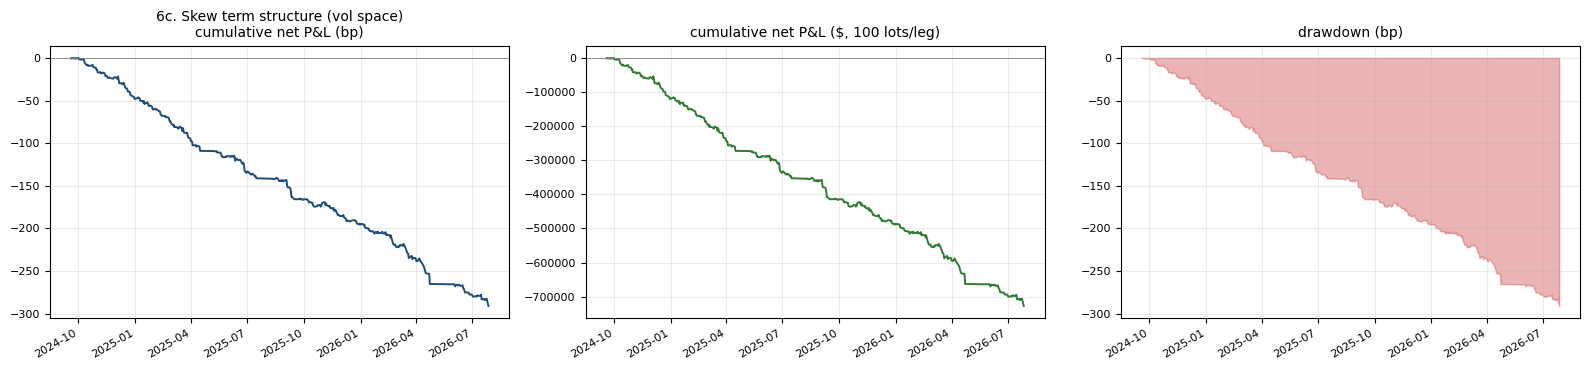


TRADE LOG (first rows)
          key  dir            structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp  net_usd  stale_frac  pkg_contracts    exit_reason
SFRU25-SFRZ25    1 skewTS SFRU25-SFRZ25  2024-09-17 2024-09-18 2024-10-11    17 -2.153    0.1333      2.5 -2.3667 -5916.65         0.0            4.0 mean_reversion
SFRH26-SFRM26    1 skewTS SFRH26-SFRM26  2024-09-30 2024-10-01 2024-10-11     8 -2.307   -0.3380      2.5 -2.8380 -7094.92         0.0            4.0 mean_reversion
SFRM25-SFRU25   -1 skewTS SFRM25-SFRU25  2024-10-01 2024-10-02 2024-10-30    20  2.462   -0.0279      2.5 -2.5279 -6319.86         0.0            4.0       max_hold
SFRH25-SFRU25   -1 skewTS SFRH25-SFRU25  2024-10-02 2024-10-03 2024-10-14     7  2.294   -0.4418      2.5 -2.9418 -7354.59         0.0            4.0 mean_reversion
SFRM25-SFRZ25   -1 skewTS SFRM25-SFRZ25  2024-10-03 2024-10-04 2024-11-01    20  2.416   -0.7256      2.5 -3.2256 -8063.89         0.0            4.0  

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0       113     0.027      -2.575      -291.013     -727532.75  -6.472   -291.175         17.124
half       114     0.035      -2.569      -292.831     -732077.25  -6.736   -292.992         16.228
  t5       212     0.005      -2.714      -575.269    -1438173.50 -11.948   -575.354          4.934
 t10       158     0.006      -2.763      -436.508    -1091270.00  -9.087   -436.670          9.709
 t20       109     0.028      -2.591      -282.446     -706115.00  -6.247   -282.607         19.009

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0       116          -3.554      -293.554  -5.791     0.026
       listed    1       113          -8.513      -291.013  -6.472     0.027
same-bar (lag 0) gross inflation: -139.5%

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 113        -8.513      -0.075     0.398      -21282.75
           0.5 113       -65.013      -0.575     0.177     -162532.75
           1.0 113      -121.513      -1.075     0.124     -303782.75
           1.5 113      -178.013      -1.575     0.062     -445032.75
           2.5 113      -291.013      -2.575     0.027     -727532.75
           4.0 113      -460.513      -4.075     0.009    -1151282.75



6c. Skew term structure (vol space) — median config (not selected)  |  momentum|ma5|w120|z1.5|t10|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 4 contracts -> position = 400 contracts across all legs
  trades   252   skipped    0   hit 0%   avg -2.975bp   avg hold 9.8d   stale 0.0%
  total    -749.72bp   $  -1,874,310   gross -119.72bp
  daily-MTM Sharpe -11.52   maxDD -749.57bp ($-1,873,931)   worst trade -6.19bp
  t(trade) -54.66   NW t(daily) -14.99   non-overlap SR -4.04   DSR p=0.000 over 108 trials

  LEAGUE ROW  6c. Skew term structure (vol space) / best-config: DEAD  (taker -291.01bp, maker -8.51bp, DSR p=0.000)

  LEAGUE ROW  6c. Skew term structure (vol space) / median-config: DEAD  (taker -749.72bp, maker -119.72bp, DSR p=0.000)


In [6]:
vidx = V.set_index(["as_of", "key"])["rr_iv_bp"].sort_index()
rows = []
for front, back in contract_pairs(SYMS, gaps=(1, 2)):
    try:
        f = vidx.xs(front, level="key")
        b = vidx.xs(back, level="key")
    except KeyError:
        continue
    j = pd.concat([f.rename("f"), b.rename("b")], axis=1).dropna()
    if j.empty:
        continue
    rows.append(pd.DataFrame({
        "as_of": j.index, "key": f"{front}-{back}", "front": front, "back": back,
        "signal": (j["b"] - j["f"]).to_numpy(), "gate": True}))
skew_ts = (pd.concat(rows, ignore_index=True) if rows else pd.DataFrame())
if len(skew_ts):
    skew_ts = add_event_distance(skew_ts)
print(f"skew term-structure rows: {len(skew_ts)}")


def builder_skew_ts(key, exec_date, direction):
    """Back-expiry risk reversal against the front's, delta-hedged daily."""
    front, back = key.split("-")
    kf = _smile_strikes(front, exec_date)
    kb = _smile_strikes(back, exec_date)
    if kf is None or kb is None:
        return None
    return Structure((
        Leg("option", back, 1.0, "P", kb[2]), Leg("option", back, -1.0, "C", kb[3]),
        Leg("option", front, -1.0, "P", kf[2]), Leg("option", front, 1.0, "C", kf[3]),
    ), label=f"skewTS {key}")


if len(skew_ts):
    out_skew = run_framework(
        "6c. Skew term structure (vol space)", signals=skew_ts, book=lab["book"],
        builder=builder_skew_ts, base=BASE, grid_spec=GRID, params=PARAMS,
        cls="A/B", note="RR(back) - RR(front) in listed normal vol, hedged daily")